In [1]:
import pandas as pd
import os

# Load the dataset
import kagglehub
path = kagglehub.dataset_download("arhamrumi/amazon-product-reviews")

# List the files in the downloaded path to find the exact CSV name
print("Files in dataset:", os.listdir(path))

# Set the file path with the dataset file name
file_path = os.path.join(path, "Reviews.csv")
df = pd.read_csv(file_path)

# Preview the data
print(df.head())


Using Colab cache for faster access to the 'amazon-product-reviews' dataset.
Files in dataset: ['Reviews.csv']
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                       

In [2]:
# Check the distribution of the new binary sentiment scores to see if classes are balanced
print(df['Score'].value_counts())

# Inspect a random raw review from the 'Text' column to identify HTML tags and noise
print(df['Text'].iloc[1])

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".


In [3]:
# Create the binary sentiment score where 4-5 stars are 1 and 1-2 stars are 0
df['sentiment_score'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

# Remove the neutral 3-star reviews to keep the analysis strictly positive or negative
df = df[df['Score'] != 3]

# Check the first few rows to verify the mapping from Score to sentiment_score
print(df[['Score', 'sentiment_score']].head())

   Score  sentiment_score
0      5                1
1      1                0
2      4                1
3      2                0
4      5                1


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources for processing
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Define the function to clean Amazon product review text
def clean_text(text):
    # Ensure the input is treated as a string to avoid errors
    text = str(text).lower()

    # Remove HTML tags often found in Amazon web-scraped data
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers to focus on sentiment words
    text = re.sub(r'[^a-z\s]', '', text)

    # Split text into individual words for filtering
    tokens = word_tokenize(text)

    # Remove common filler words that don't carry emotional weight
    stop_words = set(stopwords.words('english'))
    cleaned = [w for w in tokens if w not in stop_words]

    # Recombine words into a clean string for the vectorizer
    return " ".join(cleaned)

# Apply the cleaning function specifically to the 'Text' column
df['cleaned_review'] = df['Text'].apply(clean_text)

# Compare the raw Amazon review with the processed version
print("Original Review Snippet:\n", df['Text'].iloc[0][:150])
print("\nCleaned Review Snippet:\n", df['cleaned_review'].iloc[0][:150])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Original Review Snippet:
 I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than 

Cleaned Review Snippet:
 bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates 


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Define the input features from cleaned text and the target sentiment labels
X = df['cleaned_review']
y = df['sentiment_score']

# Split the dataset into 80% for training the model and 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the TF-IDF vectorizer to extract the top 5000 most significant words
tfidf = TfidfVectorizer(max_features=5000)

# Learn the vocabulary and convert the training reviews into numerical vectors
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert the test reviews into vectors using the vocabulary learned from training data
X_test_tfidf = tfidf.transform(X_test)

# Display the final dimensions of the numerical matrices
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Testing Matrix Shape: {X_test_tfidf.shape}")

Training Matrix Shape: (420651, 5000)
Testing Matrix Shape: (105163, 5000)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Logistic Regression model

# We use max_iter=1000 to ensure the model has enough time to find the best fit
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train_tfidf, y_train)

# Use the trained model to predict sentiment on the unseen test data
y_pred = model.predict(X_test_tfidf)

# Calculate the overall accuracy percentage
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# Generate a detailed report including Precision, Recall, and F1-Score
print("\nDetailed Performance Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Overall Accuracy: 92.99%

Detailed Performance Report:

              precision    recall  f1-score   support

    Negative       0.84      0.68      0.75     16379
    Positive       0.94      0.98      0.96     88784

    accuracy                           0.93    105163
   macro avg       0.89      0.83      0.86    105163
weighted avg       0.93      0.93      0.93    105163



In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Separate the reviews into positive and negative based on the sentiment_score
pos_reviews = df[df['sentiment_score'] == 1]['cleaned_review']
neg_reviews = df[df['sentiment_score'] == 0]['cleaned_review']

# Count word frequencies for Positive Reviews
pos_words = pd.Series(' '.join(pos_reviews).split()).value_counts()[:20]

# Count word frequencies for Negative Reviews
neg_words = pd.Series(' '.join(neg_reviews).split()).value_counts()[:20]

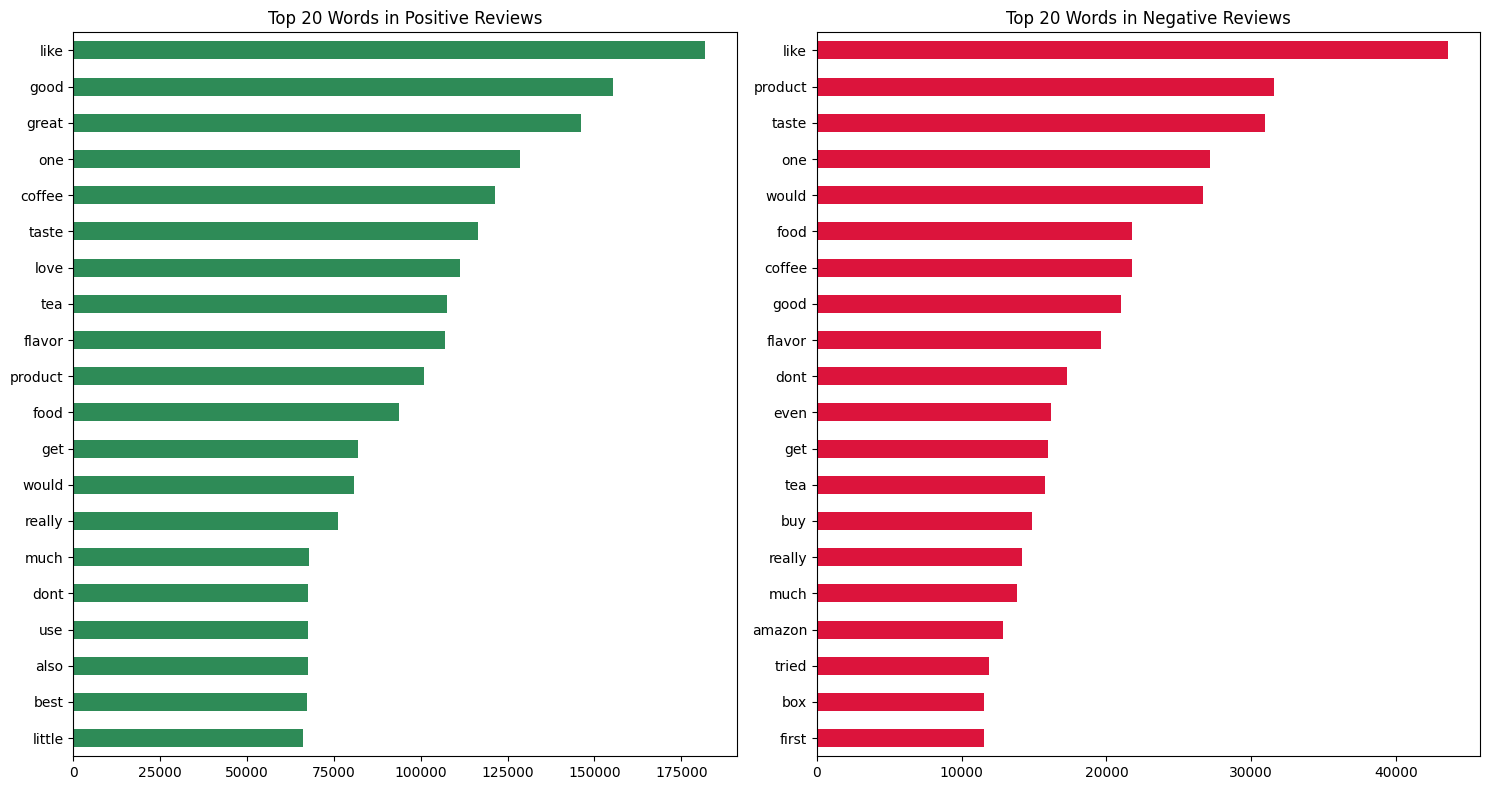

In [8]:
# Create a figure with two subplots
plt.figure(figsize=(15, 8))

# Subplot for Positive Words
plt.subplot(1, 2, 1)
pos_words.plot(kind='barh', color='seagreen')
plt.title('Top 20 Words in Positive Reviews')
plt.gca().invert_yaxis()  # Put the most frequent word at the top

# Subplot for Negative Words
plt.subplot(1, 2, 2)
neg_words.plot(kind='barh', color='crimson')
plt.title('Top 20 Words in Negative Reviews')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Initialize the Naive Bayes model
nb_model = MultinomialNB()

# 2. Train the model using the same TF-IDF training data
nb_model.fit(X_train_tfidf, y_train)

# 3. Predict on the test data
nb_preds = nb_model.predict(X_test_tfidf)

# 4. Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_preds)

# 5. Compare with Logistic Regression (assuming 'accuracy' variable exists from previous step)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Naive Bayes Accuracy:         {nb_accuracy * 100:.2f}%")

# Determine the winner
if nb_accuracy > accuracy:
    print("\nResult: Naive Bayes performed better!")
else:
    print("\nResult: Logistic Regression performed better!")

Logistic Regression Accuracy: 92.99%
Naive Bayes Accuracy:         88.17%

Result: Logistic Regression performed better!
